In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import re
import time
from shapely.geometry import Point
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from sklearn.model_selection import KFold, cross_val_score, train_test_split, GridSearchCV, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, RocCurveDisplay
from sklearn.feature_selection import SelectPercentile
from sklearn.decomposition import PCA


load dataset; preprocessing; feature engineering

In [3]:
#compute nearest boundary distance in km
def getNearestBoundaryDist(point, boundaries):
    nearestBoundary = boundaries.geometry.distance(point).min() / 1000
    return nearestBoundary

#get the type of the nearest boundary
def getNearestBoundaryType(point, boundaries):
    distances = boundaries.geometry.distance(point)
    nearestIdx = distances.idxmin()
    return boundaries.loc[nearestIdx, 'Type']


earthquakeRaw = pd.read_csv('/Users/dingleberry/Visual studio code workspace/DSC400s/DSC478/Project/earthquakes.csv')
plates = gpd.read_file("/Users/dingleberry/Visual studio code workspace/DSC400s/DSC478/Project/PB2002_plates.json")
boundaries = gpd.read_file("/Users/dingleberry/Visual studio code workspace/DSC400s/DSC478/Project/PB2002_boundaries.json")

#print(earthquakeRaw.head())
# print(plates.crs)
# print(boundaries.crs)
# print(earthquakeRaw.shape)
#print(plates.columns)
#print(boundaries.columns)

#get plate areas
plates_54009 = plates.to_crs("ESRI:54009")
plates_54009["plateArea(km2)"] = plates_54009.geometry.area / 1e6 #m2 to km2
plates = plates.merge(plates_54009[["PlateName", "plateArea(km2)"]], on="PlateName", how="left")

#fill boundary type NA values with unknown
boundaries['Type'] = boundaries['Type'].fillna('notSubduction')

#convert to geo df
coordinates = [Point(xy) for xy in zip(earthquakeRaw['Longitude'], earthquakeRaw['Latitude'])]
earthquakeGeo = gpd.GeoDataFrame(earthquakeRaw, geometry=coordinates, crs="EPSG:4326")

#project to web mercator for distance calculations (meters)
earthquakeGeo = earthquakeGeo.to_crs(epsg=3857)
plates = plates.to_crs(epsg=3857)
boundaries = boundaries.to_crs(epsg=3857)

#spacial join to find which plate polygon each earthquake lies in
gdfEQxPlates= gpd.sjoin(earthquakeGeo, plates, how='left', predicate='within')

############################
#engineer/transform features
############################

#get nearest boundary type
gdfEQxPlates['nearestBoundaryType'] = gdfEQxPlates.geometry.apply(lambda geom: getNearestBoundaryType(geom, boundaries))

#compute distance to nearest boundary
gdfEQxPlates['nearestBoundDist(km)'] = gdfEQxPlates.geometry.apply(lambda geom: getNearestBoundaryDist(geom, boundaries))

#log scale focal depth
gdfEQxPlates['logDepth'] = np.log1p(gdfEQxPlates['Focal Depth (km)'])

#transform lat/lon to sin/cos
gdfEQxPlates['lat_sin'] = np.sin(np.radians(gdfEQxPlates['Latitude']))
gdfEQxPlates['lat_cos'] = np.cos(np.radians(gdfEQxPlates['Latitude']))
gdfEQxPlates['lon_sin'] = np.sin(np.radians(gdfEQxPlates['Longitude']))
gdfEQxPlates['lon_cos'] = np.cos(np.radians(gdfEQxPlates['Longitude']))

#region clustering 
gdfEQxPlates['regionCluster'] = KMeans(n_clusters=5, random_state=0).fit_predict(gdfEQxPlates[['lat_sin', 'lat_cos','lon_sin','lon_cos']])

#transform month 
gdfEQxPlates['Mo_sin'] = np.sin(2 * np.pi * gdfEQxPlates['Mo'] / 12)
gdfEQxPlates['Mo_cos'] = np.cos(2 * np.pi * gdfEQxPlates['Mo'] / 12)

#tsu one hot encode
gdfEQxPlates['Tsu'].fillna(False)
gdfEQxPlates['Tsu'] = gdfEQxPlates['Tsu']>0

#vol one hot encode
gdfEQxPlates['Vol'].fillna(False)
gdfEQxPlates['Vol'] = gdfEQxPlates['Vol']>0


print(gdfEQxPlates.shape)
print(gdfEQxPlates.crs)
cols = gdfEQxPlates.columns
print(cols)

gdfEQxPlates = pd.get_dummies(gdfEQxPlates, columns=['nearestBoundaryType', 'PlateName', 'regionCluster'], prefix=['Boundary', 'Plate', 'region']) 

gdfEQxPlates['isSubduction'] = gdfEQxPlates['Boundary_subduction']

features = ['Year', 'Mo_sin', 'Mo_cos', 'lat_sin', 'lat_cos', 'lon_sin', 'lon_cos', 'plateArea(km2)',
            'nearestBoundDist(km)', 'logDepth', 'Mag', 'Vol', 'isSubduction'] + [col for col in gdfEQxPlates.columns if 'region' in col]#or 'Plate' in col ]

print(features)

(2597, 54)
EPSG:3857
Index(['Year', 'Mo', 'Dy', 'Hr', 'Mn', 'Sec', 'Tsu', 'Vol', 'Location Name',
       'Latitude', 'Longitude', 'Focal Depth (km)', 'Mag', 'MMI Int', 'Deaths',
       'Death Description', 'Missing', 'Missing Description', 'Injuries',
       'Injuries Description', 'Damage ($Mil)', 'Damage Description',
       'Houses Destroyed', 'Houses Destroyed Description', 'Houses Damaged',
       'Houses Damaged Description', 'Total Deaths', 'Total Death Description',
       'Total Missing', 'Total Missing Description', 'Total Injuries',
       'Total Injuries Description', 'Total Damage ($Mil)',
       'Total Damage Description', 'Total Houses Destroyed',
       'Total Houses Destroyed Description', 'Total Houses Damaged',
       'Total Houses Damaged Description', 'geometry', 'index_right', 'LAYER',
       'Code', 'PlateName', 'plateArea(km2)', 'nearestBoundaryType',
       'nearestBoundDist(km)', 'logDepth', 'lat_sin', 'lat_cos', 'lon_sin',
       'lon_cos', 'regionCluster', '

Correlation Matrix

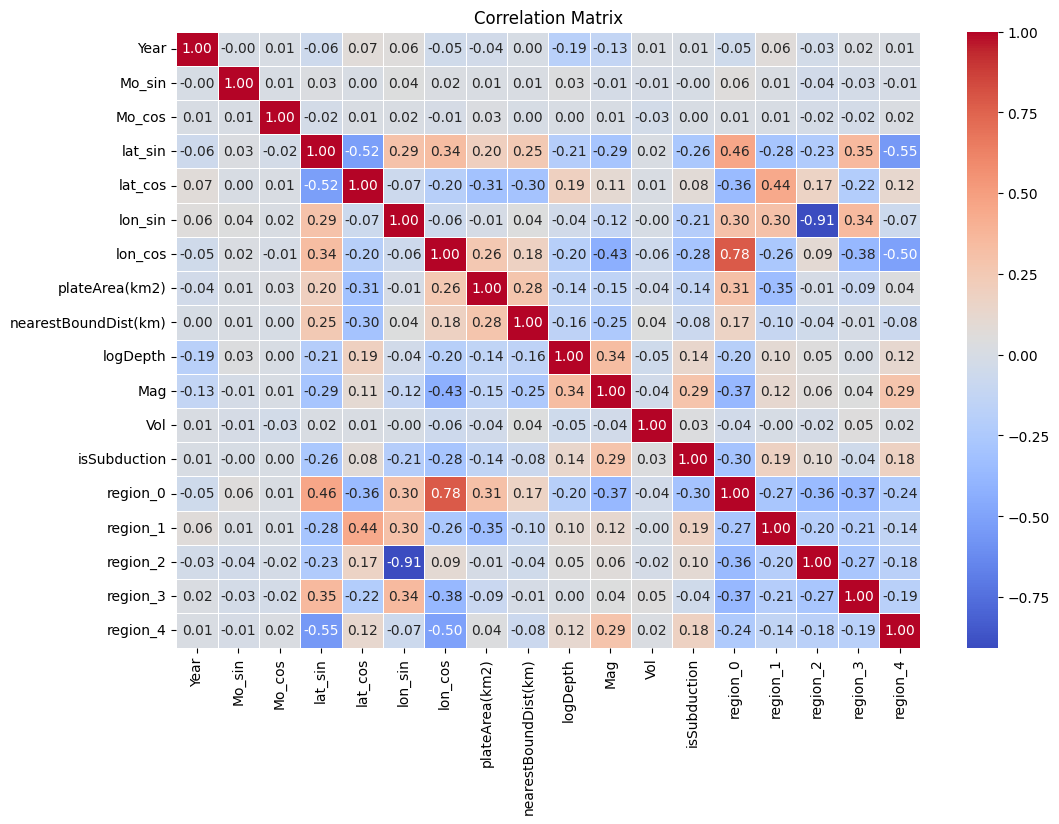

In [4]:
corrMat = gdfEQxPlates[features].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corrMat, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

Split train/test

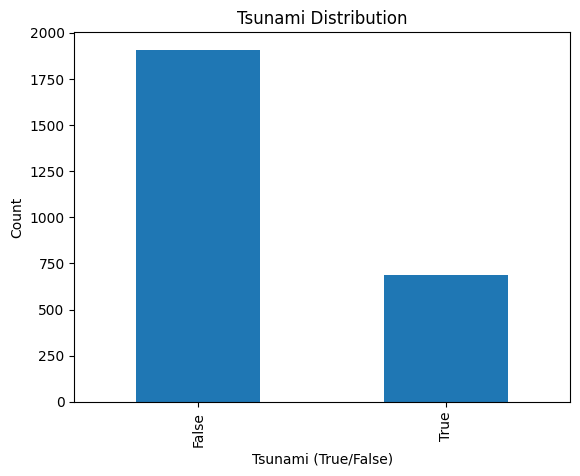

In [5]:
X = gdfEQxPlates[features]
y = gdfEQxPlates['Tsu']

histogram = y.value_counts().plot(kind='bar', title='Tsunami Distribution')
plt.xlabel('Tsunami (True/False)')
plt.ylabel('Count')
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numericFeatures = [
    'Year', 'Mo_sin', 'Mo_cos',
    'lat_sin', 'lat_cos', 'lon_sin', 'lon_cos',
    'plateArea(km2)', 'nearestBoundDist(km)',
    'logDepth', 'Mag'
]

binaryFeatures = [col for col in features if col not in numericFeatures]

scaler = StandardScaler()

#fit on training numeric features only
X_train_scaled_numeric = scaler.fit_transform(X_train[numericFeatures])
X_test_scaled_numeric  = scaler.transform(X_test[numericFeatures])

X_train_scaled_numeric = pd.DataFrame(X_train_scaled_numeric, columns=numericFeatures, index=X_train.index)
X_test_scaled_numeric = pd.DataFrame(X_test_scaled_numeric, columns=numericFeatures, index=X_test.index)

X_train_scaled = pd.concat([X_train_scaled_numeric, X_train[binaryFeatures]], axis=1)
X_test_scaled  = pd.concat([X_test_scaled_numeric, X_test[binaryFeatures]], axis=1)


hist plots of numeric features

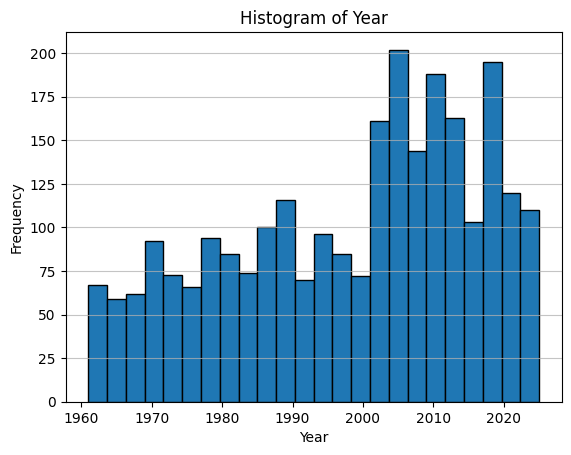

visual #0 done


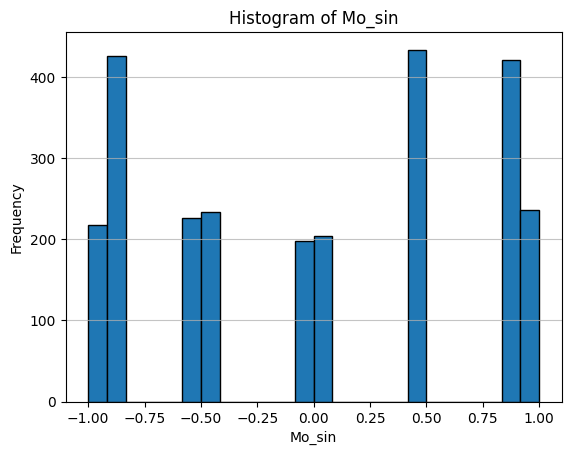

visual #1 done


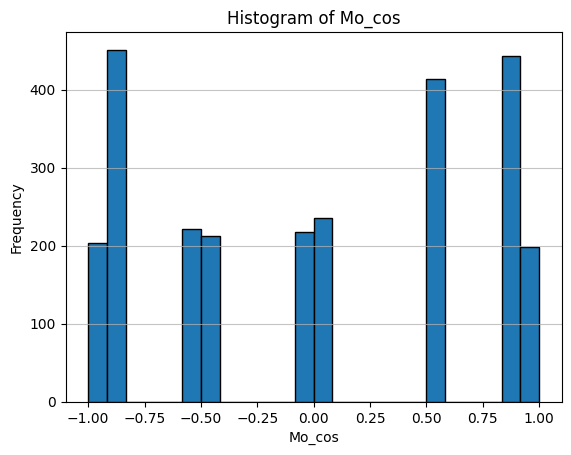

visual #2 done


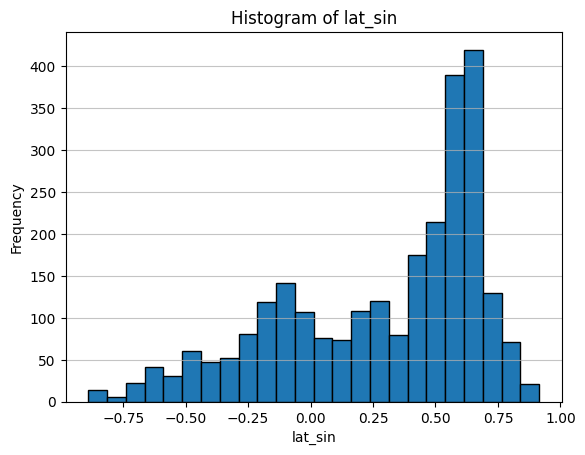

visual #3 done


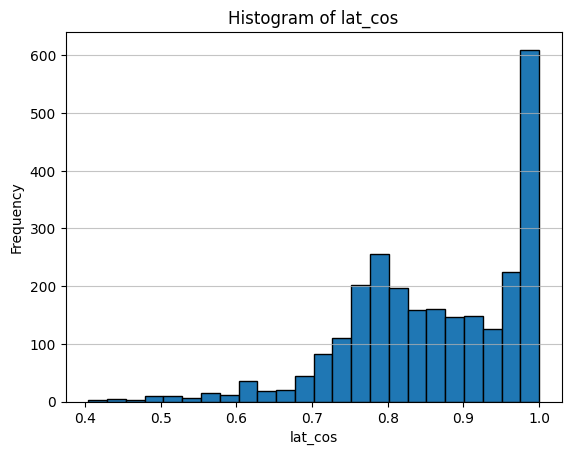

visual #4 done


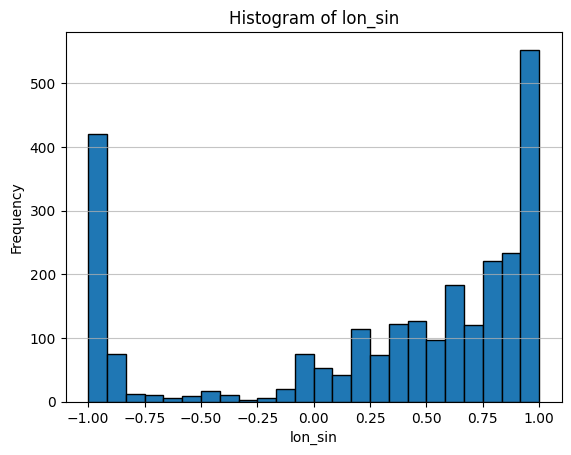

visual #5 done


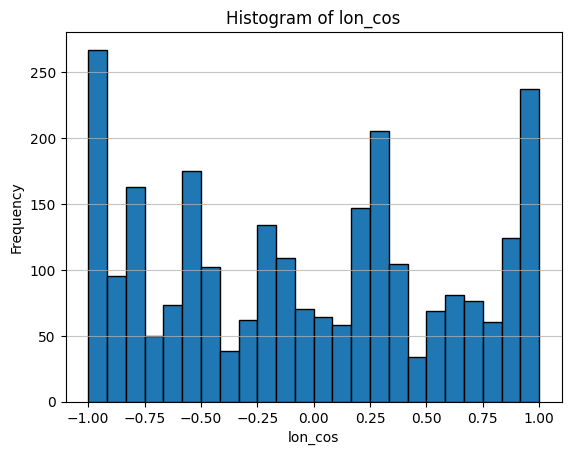

visual #6 done


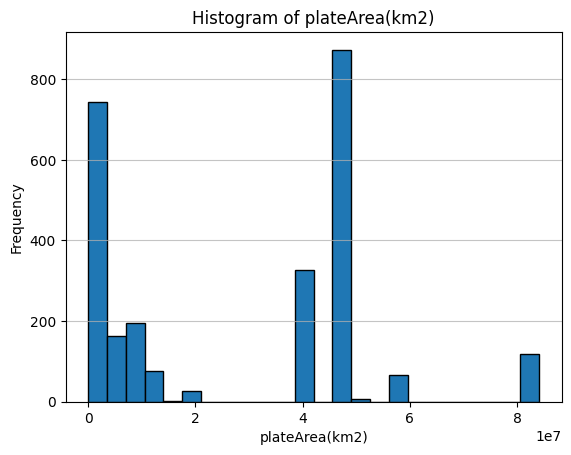

visual #7 done


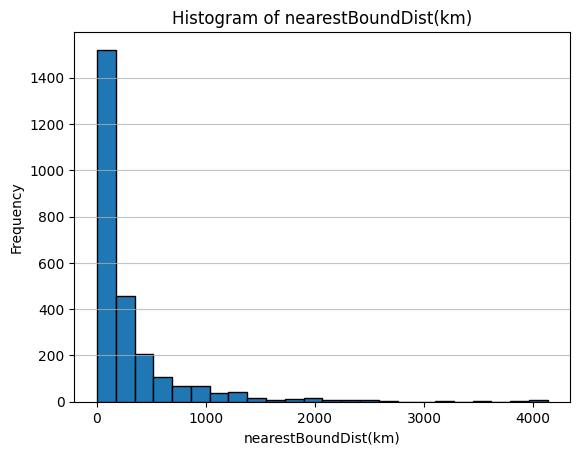

visual #8 done


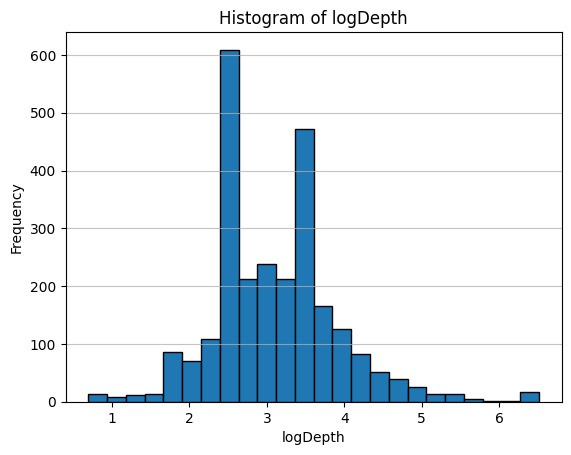

visual #9 done


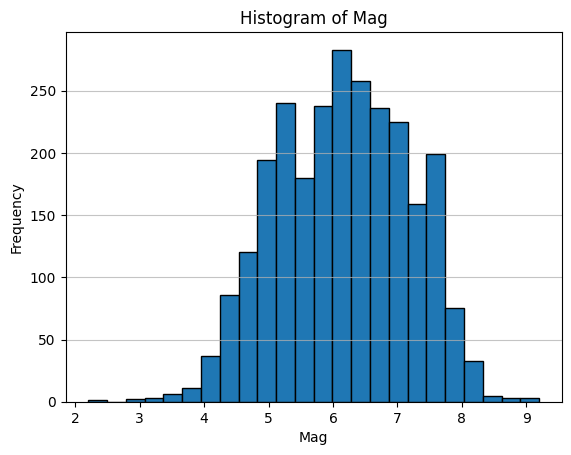

visual #10 done


In [6]:
count = 0
for col in numericFeatures:
    if col in 'vol':
        break
    plt.hist(gdfEQxPlates[col].dropna(), bins=24, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()
    print(f"visual #{count} done")
    count+=1

quick decision tree

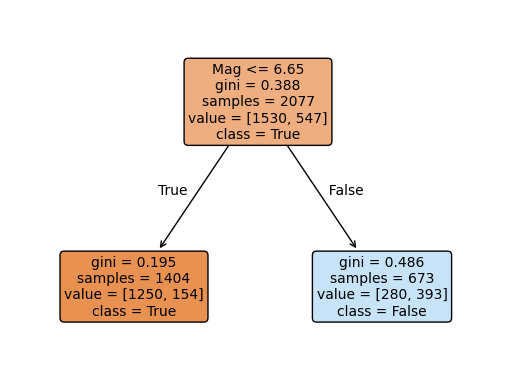

Model Accuracy: 0.7673
[[301  77]
 [ 44  98]]


In [7]:
model = DecisionTreeClassifier(max_depth=1)
model.fit(X_train, y_train)
tree.plot_tree(model,
                   feature_names=X_train.columns,
                   class_names=[str(c) for c in y_train.unique()],
                   filled=True,
                   rounded=True,
                   fontsize=10)

plt.show()

modelacc = model.score(X_test, y_test)
print(f"Model Accuracy: {modelacc:.4f}")
confusion_matrix(y_test, model.predict(X_test))
print(confusion_matrix(y_test, model.predict(X_test)))

feature importances

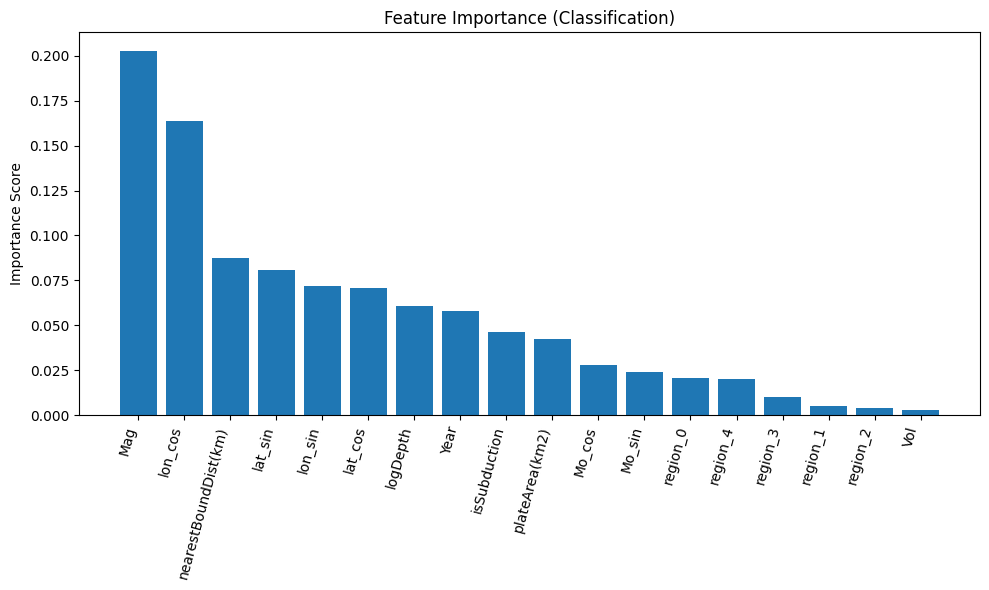

In [8]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

importances = model.feature_importances_
featureNames = X_train.columns

indices = np.argsort(importances)[::-1]
sortedFeatures = featureNames[indices]
sortedImportances = importances[indices]

plt.figure(figsize=(10, 6))
plt.bar(sortedFeatures, sortedImportances)
plt.xticks(rotation=75, ha='right')
plt.title("Feature Importance (Classification)")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

pca

Number of components to retain 95% variance: 11


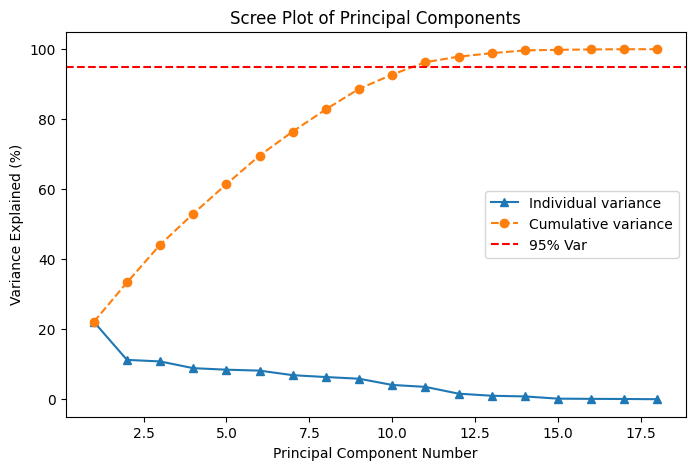

In [9]:
pca = PCA()
X_trainPCA = pca.fit(X_train_scaled).transform(X_train_scaled)
varPercentage = pca.explained_variance_ratio_*100
cumVar = np.cumsum(varPercentage)

r = np.argmax(cumVar >= 95) + 1 
print(f"Number of components to retain 95% variance: {r}")

plt.figure(figsize=(8,5))
plt.plot(range(1, len(varPercentage) + 1), varPercentage, marker='^', label='Individual variance')
plt.plot(range(1, len(cumVar) + 1), cumVar, marker='o', linestyle='--', label='Cumulative variance')
plt.axhline(95, color='r', linestyle='--', label='95% Var')
plt.xlabel('Principal Component Number')
plt.ylabel('Variance Explained (%)')
plt.title('Scree Plot of Principal Components')
plt.legend()
plt.show()

feature selection

random forest:


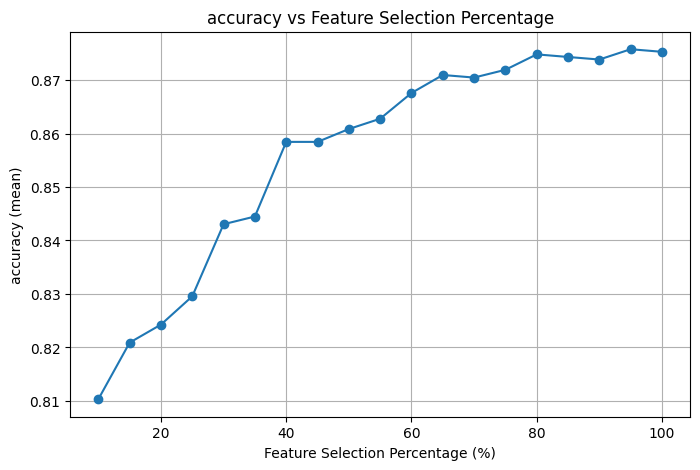


Overall Best accuracy: 0.8758
Best feature selection percentage: 95%
gradient boosting:


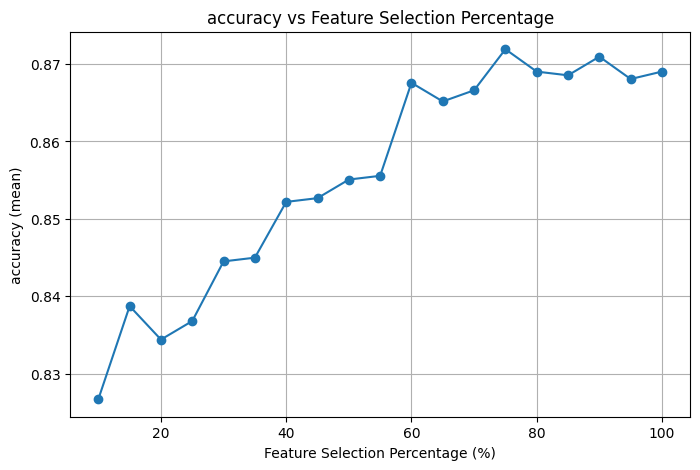


Overall Best accuracy: 0.8719
Best feature selection percentage: 75%
svm:


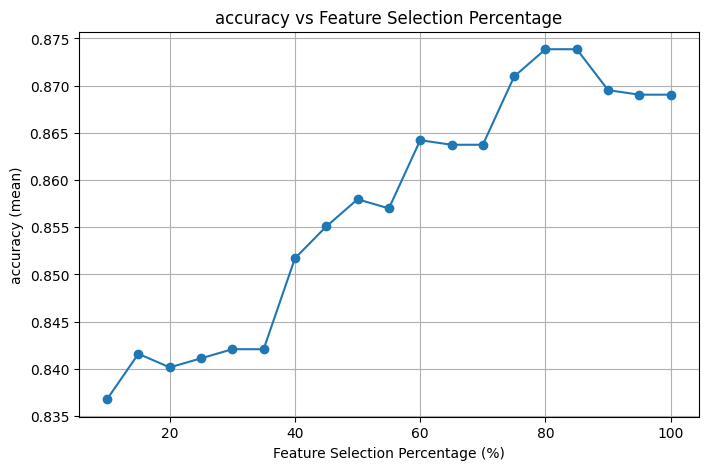


Overall Best accuracy: 0.8739
Best feature selection percentage: 85%
sdg:


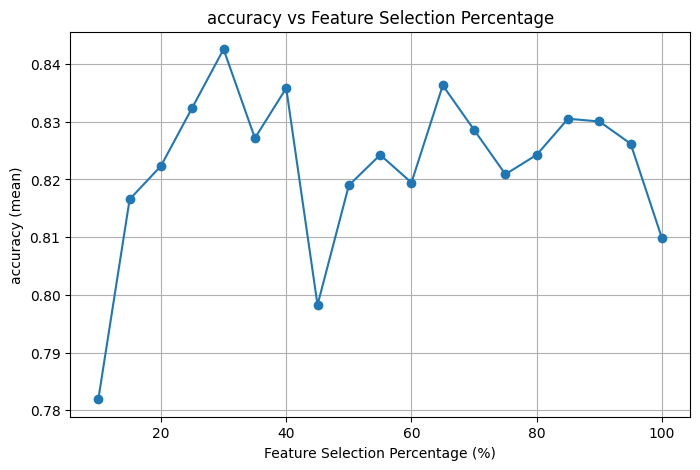


Overall Best accuracy: 0.8426
Best feature selection percentage: 30%


In [10]:
def selectFeatures(X, y, model, k=5, doPrints=False):
    features = X.columns.tolist()
    cv = KFold(n_splits=k, shuffle=True, random_state=33)

    accFeaturesPerc = {}

    for p in range(10, 101,5):
        fs = SelectPercentile(percentile=p)
        xFs = fs.fit_transform(X, y)
        accr = cross_val_score(model, xFs, y, scoring='accuracy', cv=cv)
        boolSelected = fs.get_support()

        selectedFeatures = [x for i,x in enumerate(features) if boolSelected[i]]

        accFeaturesPerc[p] = (accr.mean(), selectedFeatures)
        if doPrints:
            print(f"\n--- Feature Selection: Top {p}% ---")
            print(f"accuracy (mean): {accr.mean():.4f}")
            print(f"number of features selected: {len(selectedFeatures)} (top {p}%)")
            print(f"Selected features: {selectedFeatures.tolist()}")

    maxAcc = max([v[0] for v in accFeaturesPerc.values()])
    bestPerc = [k for k,v in accFeaturesPerc.items() if v[0]==maxAcc][0]

    plt.figure(figsize=(8, 5))
    plt.plot(list(accFeaturesPerc.keys()), [v[0] for v in accFeaturesPerc.values()], marker='o')
    plt.title("accuracy vs Feature Selection Percentage")
    plt.xlabel("Feature Selection Percentage (%)")
    plt.ylabel("accuracy (mean)")
    plt.grid(True)
    plt.show()
    print(f"\nOverall Best accuracy: {maxAcc:.4f}")
    print(f"Best feature selection percentage: {bestPerc}%")
    
    return bestPerc, accFeaturesPerc[bestPerc][1] 

rfClf = RandomForestClassifier()
rfClf.fit(X_train_scaled,y_train)

gbClf = GradientBoostingClassifier()
rfClf.fit(X_train_scaled,y_train)

svmClf = SVC()
svmClf.fit(X_train_scaled,y_train)

sdgClf = SGDClassifier()
sdgClf.fit(X_train_scaled,y_train)

# nnClf = MLPClassifier()
# nnClf.fit(X_train_scaled, y_train)

print(30*"=")
print("random forest:")
print(30*"=")
bestRfPerc, rfFeat = selectFeatures(X_train_scaled, y_train, rfClf)
print(30*"=")
print("gradient boosting:")
print(30*"=")
bestGbPerc, gbFeat =selectFeatures(X_train_scaled, y_train, gbClf)
print(30*"=")
print("svm:")
print(30*"=")
bestSvmPerc, svmFeat =selectFeatures(X_train_scaled, y_train, svmClf)
print(30*"=")
print("sdg:")
print(30*"=")
bestSgdPerc, sgdFeat =selectFeatures(X_train_scaled, y_train, sdgClf)
# print(30*"=")
# print("neural network:")
# print(30*"=")
# selectFeatures(X_train_scaled, y_train, nnClf)

Parameter tuning

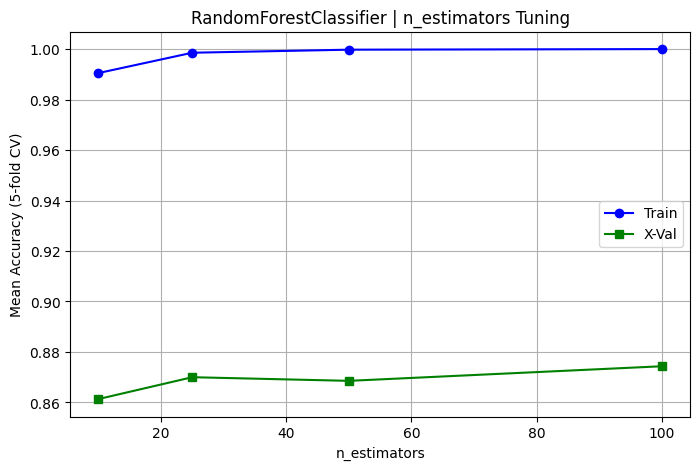


Best n_estimators: 100 with Validation accuracy: 0.8743


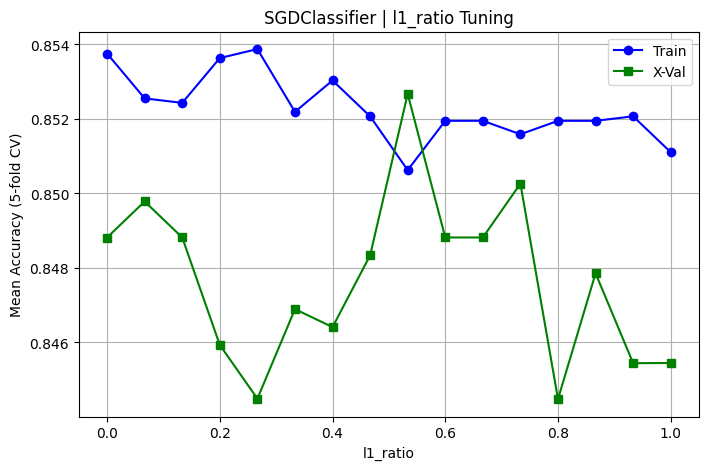


Best l1_ratio: 0.5333333333333333 with Validation accuracy: 0.8527


In [11]:
def paraTuning(X, y, model, paramName, paramValues, k=5, isScaled=True, doPrints=False):
    cv = KFold(n_splits=k, shuffle=True, random_state=33)
    train_acc = np.zeros(len(paramValues))
    val_acc = np.zeros(len(paramValues))

    for i, p in enumerate (paramValues):
            
        model.set_params(**{paramName:p})
        
        fold_train_acc = []
        fold_val_acc= []
        #manual k-fold cv
        for trainIdx, valIdx in cv.split(X):
            if hasattr(X, 'iloc'):
                xTrainCV, xValCV = X.iloc[trainIdx], X.iloc[valIdx]
            else:
                xTrainCV, xValCV = X[trainIdx], X[valIdx]

            if hasattr(y, 'iloc'):
                yTrainCV, yValCV = y.iloc[trainIdx], y.iloc[valIdx]
            else:
                yTrainCV, yValCV = y[trainIdx], y[valIdx]

            if isScaled:
                xtrainScaledNum = scaler.fit_transform(xTrainCV[numericFeatures])
                xtestScaledNum  = scaler.transform(xValCV[numericFeatures])

                xtrainScaledNum = pd.DataFrame(xtrainScaledNum, columns=numericFeatures, index=xTrainCV.index)
                xtestScaledNum = pd.DataFrame(xtestScaledNum, columns=numericFeatures, index=xValCV.index)

                xTrainCV = pd.concat([xtrainScaledNum, xTrainCV[binaryFeatures]], axis=1)
                xValCV  = pd.concat([xtestScaledNum, xValCV[binaryFeatures]], axis=1)

            model.fit(xTrainCV, yTrainCV)
            predTrain = model.predict(xTrainCV)
            predVal = model.predict(xValCV)

            fold_train_acc.append(accuracy_score(yTrainCV, predTrain))
            fold_val_acc.append(accuracy_score(yValCV, predVal))

        train_acc[i] = np.mean(fold_train_acc)
        val_acc[i] = np.mean(fold_val_acc)
            
       
    # plot the training and testing scores in a log scale
    plt.figure(figsize=(8, 5))
    plt.plot(paramValues, train_acc, label='Train', marker='o', c='b')
    plt.plot(paramValues, val_acc, label='X-Val', marker='s', c='g')
    plt.xlabel(paramName)
    plt.ylabel("Mean Accuracy (5-fold CV)")
    plt.title(f"{model.__class__.__name__} | {paramName} Tuning")
    plt.legend()
    plt.grid(True)
    plt.show()

    bestIdx = np.argmax(val_acc)
    bestParamValue = paramValues[bestIdx]

    print(f"\nBest {paramName}: {bestParamValue} with Validation accuracy: {val_acc[bestIdx]:.4f}")

    return bestParamValue

#must used unscaled!

bestNumEstimators = paraTuning(X_train, y_train, RandomForestClassifier(), 'n_estimators', [10,25,50,100])

bestL1Ratio = paraTuning(X_train, y_train, SGDClassifier(alpha=.01, penalty='elasticnet'), "l1_ratio", paramValues=np.linspace(0, 1, 16))


Grid Search param tuning (will take forever to run) should test some ranges in the above cell

In [12]:
#######################
#random forest
#######################
pipeRF = Pipeline([('featureSelect', SelectPercentile(percentile=bestRfPerc)), ('clf', RandomForestClassifier())])
paramGridRF = {
    'clf__n_estimators': np.arange(1, 100, 5),
    'clf__max_depth': [1, 5, 10, 15, 20, 25],
    'clf__min_samples_split': [2, 3, 4, 5]
}

gridSearchRF = GridSearchCV(pipeRF, paramGridRF, cv=5, scoring='accuracy')
gridSearchRF.fit(X_train_scaled, y_train)

bestParamsRF = {k.replace('clf__', ''): v for k, v in gridSearchRF.best_params_.items()}
bestAccRF = gridSearchRF.best_score_
print(f"\nBest Random Forest Parameters: {bestParamsRF} with accuracy: {bestAccRF:.4f}")


######################
#gradient boosting
######################
pipeGB = Pipeline([('featureSelect', SelectPercentile(percentile=bestGbPerc)), ('clf', GradientBoostingClassifier())])
paramGridGB = {
    'clf__n_estimators': np.arange(1, 100, 5),
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__max_depth': [2, 3, 5]
}

gridSearchGB = GridSearchCV(pipeGB, paramGridGB, cv=5, scoring='accuracy')
gridSearchGB.fit(X_train_scaled, y_train)

bestParamsGB = {k.replace('clf__', ''): v for k, v in gridSearchGB.best_params_.items()}
bestAccGB = gridSearchGB.best_score_
print(f"\nBest Gradient Boosting Parameters: {bestParamsGB} with accuracy: {bestAccGB:.4f}")


##############
#svm
##############
pipeSVM = Pipeline([('featureSelect', SelectPercentile(percentile=bestSvmPerc)), ('clf', SVC())])
paramGridSVM = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 'auto'],
    'clf__kernel': ['rbf']  #add 'linear' and ‘poly’
}

gridSearchSVM = GridSearchCV(pipeSVM, paramGridSVM, cv=5, scoring='accuracy')
gridSearchSVM.fit(X_train_scaled, y_train)

bestParamsSVM = {k.replace('clf__', ''): v for k, v in gridSearchSVM.best_params_.items()}
bestAccSVM = gridSearchSVM.best_score_
print(f"\nBest SVM Parameters: {bestParamsSVM} with accuracy: {bestAccSVM:.4f}")

##############
#sdg
##############
pipeSGD = Pipeline([('featureSelect', SelectPercentile(percentile=bestSgdPerc)), ('clf', SGDClassifier())])
paramGridSGD = {
    'clf__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10],
    'clf__penalty': ['l1', 'l2']
}

gridSearchSGD = GridSearchCV(pipeSGD, paramGridSGD, cv=5, scoring='accuracy')
gridSearchSGD.fit(X_train_scaled, y_train)

bestParamsSGD = {k.replace('clf__', ''): v for k, v in gridSearchSGD.best_params_.items()}
bestAccSGD = gridSearchSGD.best_score_
print(f"\nBest SGD Parameters: {bestParamsSGD} with accuracy: {bestAccSGD:.4f}")




Best Random Forest Parameters: {'max_depth': 25, 'min_samples_split': 3, 'n_estimators': np.int64(76)} with accuracy: 0.8801

Best Gradient Boosting Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': np.int64(36)} with accuracy: 0.8685

Best SVM Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'} with accuracy: 0.8734

Best SGD Parameters: {'alpha': 0.01, 'penalty': 'l1'} with accuracy: 0.8421


Pipelining models with feature selection and best parameters


===== Random Forest =====
Train Accuracy: 0.9995
Test Accuracy: 0.8769
Confusion Matrix:
[[353  25]
 [ 39 103]]
AUC: 0.9323


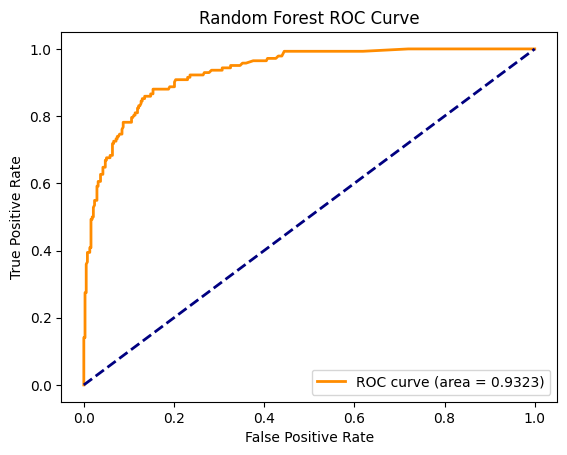


===== Gradient Boosting =====
Train Accuracy: 0.9485
Test Accuracy: 0.8731
Confusion Matrix:
[[352  26]
 [ 40 102]]
AUC: 0.9280


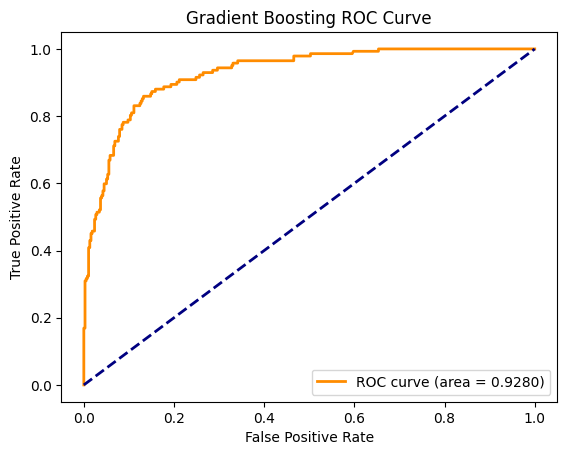


===== SVM =====
Train Accuracy: 0.9104
Test Accuracy: 0.8827
Confusion Matrix:
[[352  26]
 [ 35 107]]
AUC: 0.9258


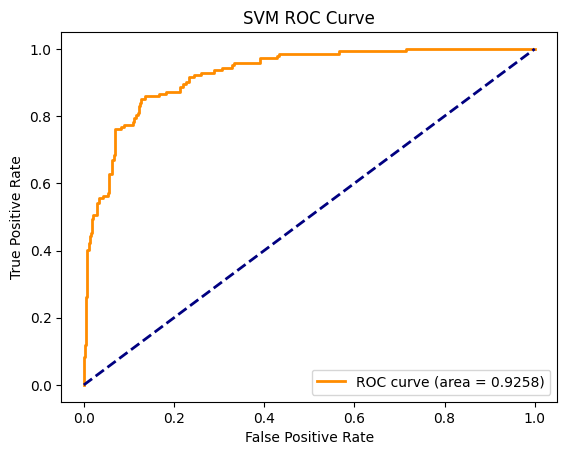


===== SGD =====
Train Accuracy: 0.8368
Test Accuracy: 0.8269
Confusion Matrix:
[[340  38]
 [ 52  90]]
AUC: 0.8630


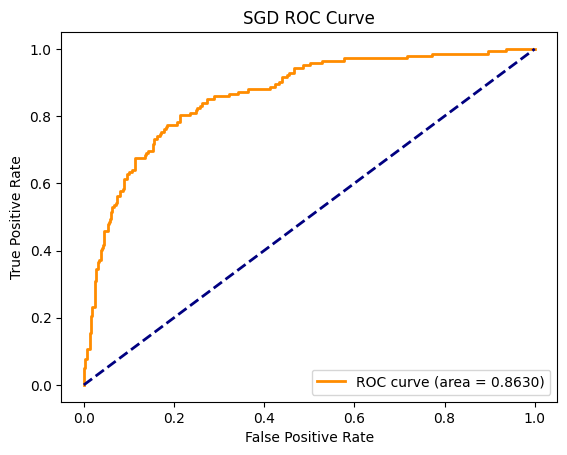

In [13]:
#final models
finalPipeRF = Pipeline([('featureSelect', SelectPercentile(percentile=bestRfPerc)), ('clf', RandomForestClassifier(**bestParamsRF))])
finalPipeGB = Pipeline([('featureSelect', SelectPercentile(percentile=bestGbPerc)), ('clf', GradientBoostingClassifier(**bestParamsGB))])
finalPipeSVM = Pipeline([('featureSelect', SelectPercentile(percentile=bestSvmPerc)), ('clf', SVC(**bestParamsSVM, probability=True))])
finalPipeSGD = Pipeline([('featureSelect', SelectPercentile(percentile=bestSgdPerc)), ('clf', SGDClassifier(**bestParamsSGD ))])

#fit scaled training data 
finalPipeRF.fit(X_train_scaled, y_train)
finalPipeGB.fit(X_train_scaled, y_train)
finalPipeSVM.fit(X_train_scaled, y_train)
finalPipeSGD.fit(X_train_scaled, y_train)

#predict test data
preds = {
    'Random Forest': finalPipeRF.predict(X_test_scaled),
    'Gradient Boosting': finalPipeGB.predict(X_test_scaled),
    'SVM': finalPipeSVM.predict(X_test_scaled),
    'SGD': finalPipeSGD.predict(X_test_scaled)
}

#prob estimates on test data
probs = {}
probs['Random Forest'] = finalPipeRF.predict_proba(X_test_scaled)[:,1]
probs['Gradient Boosting'] = finalPipeGB.predict_proba(X_test_scaled)[:,1]
probs['SVM'] = finalPipeSVM.predict_proba(X_test_scaled)[:,1]
probs['SGD'] = finalPipeSGD.decision_function(X_test_scaled)

for name, y_pred in preds.items():
    print(f"\n===== {name} =====")
    
    #accuracy
    train_pred = eval(f'finalPipe{re.sub(r'[^A-Z]', '', name)}.predict(X_train_scaled)')
    trainAcc = accuracy_score(y_train, train_pred)
    testAcc = accuracy_score(y_test, y_pred)
    print(f"Train Accuracy: {trainAcc:.4f}")
    print(f"Test Accuracy: {testAcc:.4f}")
    
    #confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)
    
    #ROC & AUC
    fpr, tpr, _ = roc_curve(y_test, probs[name])
    roc_auc = auc(fpr, tpr)
    print(f"AUC: {roc_auc:.4f}")
    
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name} ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

Cross val with full dataset, non scaled, optimized pipeline. 


===== Evaluating: RandomForest =====
RandomForest Accuracy: 0.787 (+/- 0.356)
RandomForest AUC: 0.901 (+/- 0.139)
RandomForest Runtime: 0.87 sec

===== Evaluating: GradientBoosting =====
GradientBoosting Accuracy: 0.746 (+/- 0.387)
GradientBoosting AUC: 0.863 (+/- 0.190)
GradientBoosting Runtime: 0.99 sec

===== Evaluating: SVM =====
SVM Accuracy: 0.733 (+/- 0.017)
SVM AUC: 0.702 (+/- 0.075)
SVM Runtime: 2.87 sec

===== Evaluating: SGD =====
SGD Accuracy: 0.762 (+/- 0.064)
SGD AUC: 0.826 (+/- 0.044)
SGD Runtime: 0.03 sec

================ Final Model Comparison Table ================

           Model  Mean_Accuracy  Std_Accuracy  Mean_AUC  Std_AUC  Runtime_sec
    RandomForest       0.787177      0.356271  0.900761 0.138645     0.872587
GradientBoosting       0.745605      0.386556  0.862673 0.189929     0.994705
             SGD       0.762022      0.064380  0.826298 0.044174     0.033381
             SVM       0.733161      0.017171  0.702141 0.075335     2.865336


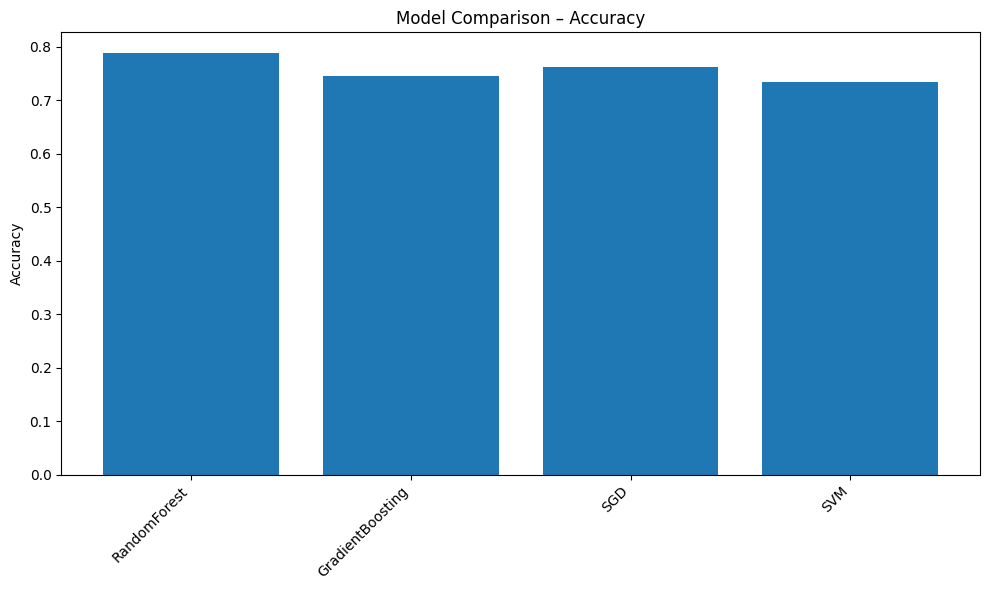

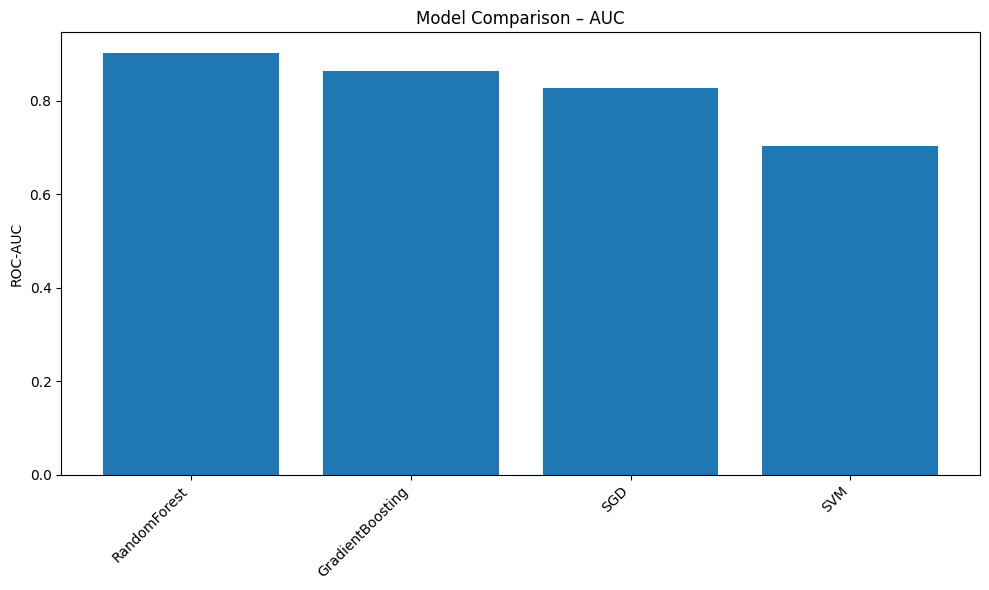

In [14]:
scorers = {"Acc": "accuracy", "AUC": "roc_auc"}

finalModels = {
    "RandomForest": finalPipeRF,
    "GradientBoosting": finalPipeGB,
    "SVM": finalPipeSVM,
    "SGD": finalPipeSGD
}

results = []


for modelName, pipe in finalModels.items():
    print(f"\n===== Evaluating: {modelName} =====")

    start_ts = time.time()

    scores = cross_validate(
        pipe,
        X,
        y,
        scoring=scorers,
        cv=5,
        return_train_score=False
    )

    accScores = scores["test_Acc"]
    aucScores = scores["test_AUC"]

    results.append({
        "Model": modelName,
        "Mean_Accuracy": accScores.mean(),
        "Std_Accuracy": accScores.std() * 2,
        "Mean_AUC": aucScores.mean(),
        "Std_AUC": aucScores.std() * 2,
        "Runtime_sec": time.time() - start_ts
    })

    print(f"{modelName} Accuracy: {accScores.mean():.3f} (+/- {accScores.std()*2:.3f})")
    print(f"{modelName} AUC: {aucScores.mean():.3f} (+/- {aucScores.std()*2:.3f})")
    print(f"{modelName} Runtime: {time.time()-start_ts:.2f} sec")


results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Mean_AUC", ascending=False)

print("\n================ Final Model Comparison Table ================\n")
print(results_df.to_string(index=False))


plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Mean_Accuracy"])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.title("Model Comparison – Accuracy")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Mean_AUC"])
plt.xticks(rotation=45, ha='right')
plt.ylabel("ROC-AUC")
plt.title("Model Comparison – AUC")
plt.tight_layout()
plt.show()

